In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("train.csv")

print(df.shape)        # rows and columns
print(df.head())       # first 5 rows
print(df.info())       # column types and missing values
print(df.describe())   # basic statistics

(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Duplicates: 24259


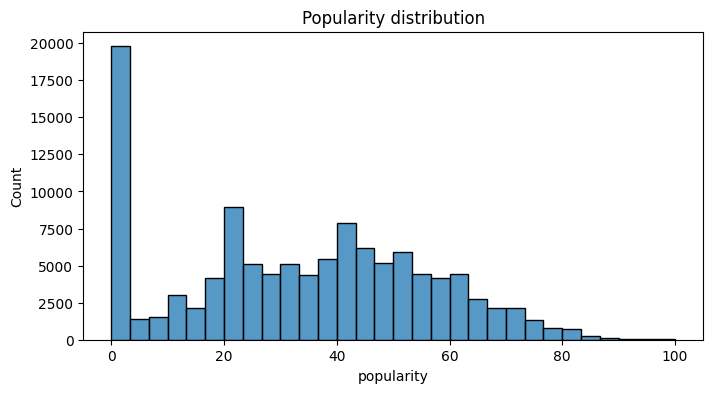

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

# 1. Missing values and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated(subset="track_id").sum())

# 2. Distribution of popularity
plt.figure(figsize=(8, 4))
sns.histplot(df["popularity"], bins=30)
plt.title("Popularity distribution")
plt.show()

In [7]:
# Drop the useless index column
df = df.drop(columns=["Unnamed: 0"])

# Drop the row with missing values
df = df.dropna()

# Keep one row per track
df = df.drop_duplicates(subset="track_id")

print(df.shape)

(89740, 20)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load
df = pd.read_csv("train.csv")

# Clean
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna()
df = df.drop_duplicates(subset="track_id")

print(df.shape)

(89740, 20)


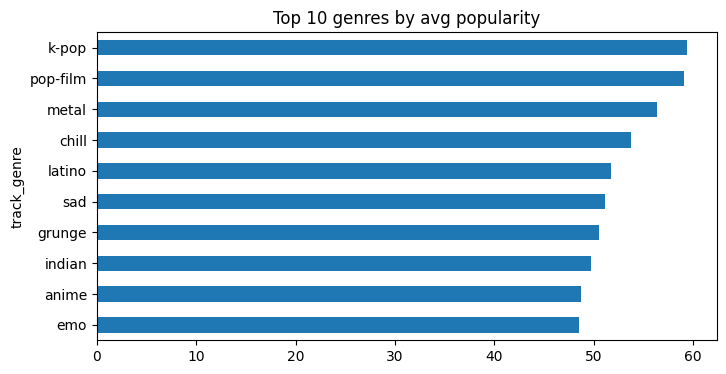

In [9]:
# Top 10 genres by average popularity
top_genres = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10)
top_genres.plot(kind="barh", figsize=(8, 4), title="Top 10 genres by avg popularity")
plt.gca().invert_yaxis()
plt.show()

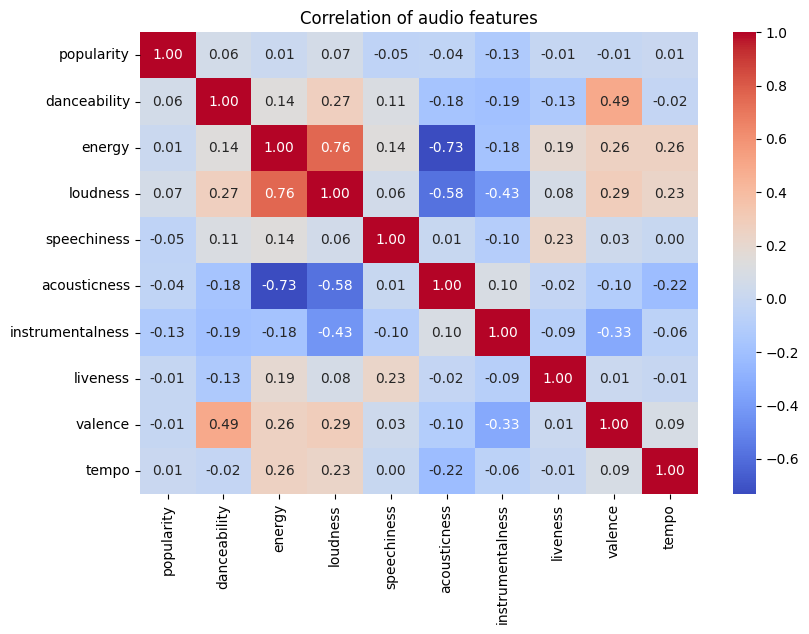

In [10]:
# Correlation heatmap
features = ["popularity", "danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
plt.figure(figsize=(9, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of audio features")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Choose features
num_features = ["danceability", "energy", "loudness", "speechiness", "acousticness",
                "instrumentalness", "liveness", "valence", "tempo", "duration_ms"]

X = df[num_features].copy()
X["explicit"] = df["explicit"].astype(int)

# Turn genre into numbers (one column per genre)
X = pd.concat([X, pd.get_dummies(df["track_genre"])], axis=1)
y = df["popularity"]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: always guess the average popularity
baseline = [y_train.mean()] * len(y_test)
print("Baseline MAE:", round(mean_absolute_error(y_test, baseline), 2))

# Random Forest
model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Model MAE:", round(mean_absolute_error(y_test, pred), 2))
print("Model R2:", round(r2_score(y_test, pred), 3))

Baseline MAE: 17.12
Model MAE: 14.55
Model R2: 0.19


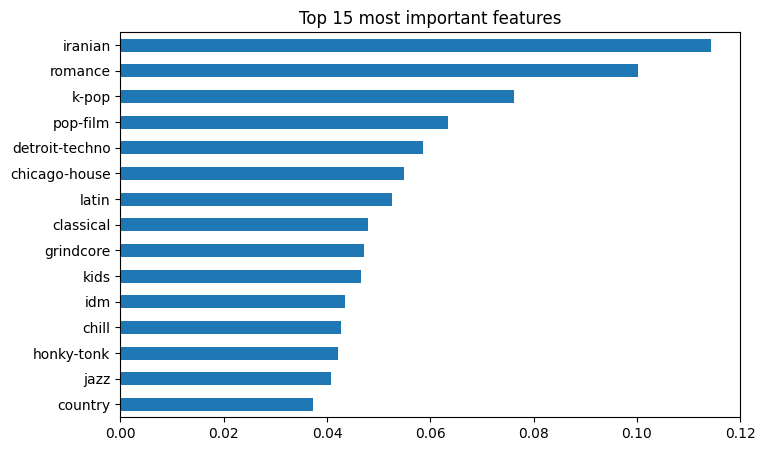

In [12]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(
    kind="barh", figsize=(8, 5), title="Top 15 most important features")
plt.gca().invert_yaxis()
plt.show()

In [13]:
# Remove tracks with popularity 0, then repeat the split, training and scoring
mask = df["popularity"] > 0
X2, y2 = X[mask], y[mask]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

baseline2 = [y_train2.mean()] * len(y_test2)
print("Baseline MAE (no zeros):", round(mean_absolute_error(y_test2, baseline2), 2))

model2 = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
model2.fit(X_train2, y_train2)
pred2 = model2.predict(X_test2)

print("Model MAE (no zeros):", round(mean_absolute_error(y_test2, pred2), 2))
print("Model R2 (no zeros):", round(r2_score(y_test2, pred2), 3))

Baseline MAE (no zeros): 15.24
Model MAE (no zeros): 11.79
Model R2 (no zeros): 0.306


In [14]:
g = df.groupby("track_genre")["popularity"].agg(avg="mean", zero_share=lambda s: (s == 0).mean())
print(g.loc[["iranian", "romance", "k-pop", "pop-film"]])

                   avg  zero_share
track_genre                       
iranian       2.224696    0.655870
romance       3.549779    0.613938
k-pop        59.423581    0.004367
pop-film     59.096933    0.002454


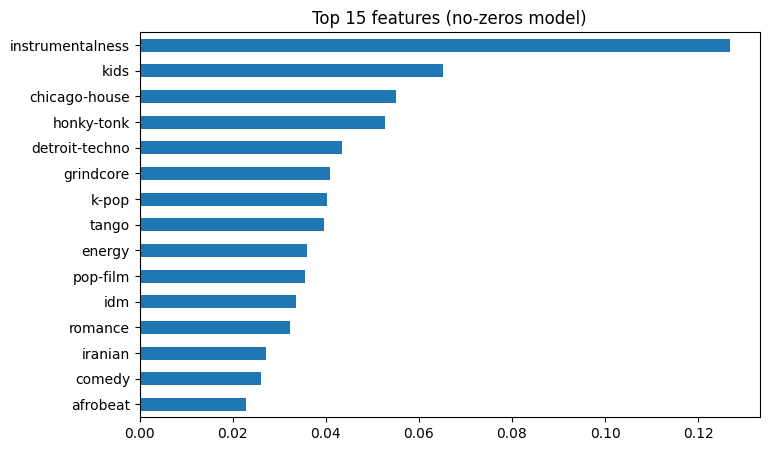

In [15]:
imp2 = pd.Series(model2.feature_importances_, index=X.columns)
imp2.sort_values(ascending=False).head(15).plot(
    kind="barh", figsize=(8, 5), title="Top 15 features (no-zeros model)")
plt.gca().invert_yaxis()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

vibe = ["danceability", "energy", "valence", "acousticness"]

# Put all features on the same scale
scaled = StandardScaler().fit_transform(df[vibe])

# Group songs into 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled)

# What does each cluster look like?
print(df.groupby("cluster")[vibe + ["popularity"]].mean().round(2))
print(df["cluster"].value_counts().sort_index())

         danceability  energy  valence  acousticness  popularity
cluster                                                         
0                0.69    0.75     0.70          0.15       33.12
1                0.62    0.47     0.53          0.65       34.14
2                0.36    0.23     0.20          0.82       30.02
3                0.47    0.80     0.29          0.07       34.10
cluster
0    30202
1    19059
2    12753
3    27726
Name: count, dtype: int64


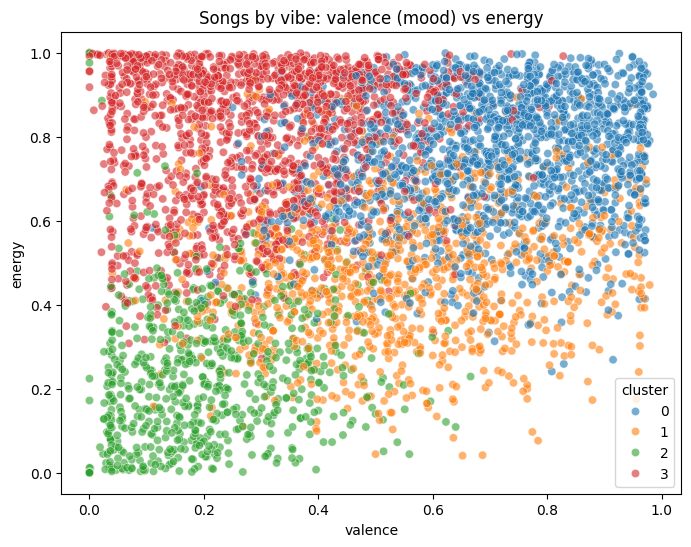

In [17]:
sample = df.sample(5000, random_state=42)   # a sample keeps the chart readable
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x="valence", y="energy", hue="cluster",
                palette="tab10", alpha=0.6)
plt.title("Songs by vibe: valence (mood) vs energy")
plt.show()

In [21]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# 1. Compare three models on the same test set
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": model,          # already trained earlier
}
rows = []
for name, m in models.items():
    if name != "Random Forest":
        m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows.append([name,
                 mean_absolute_error(y_test, p),
                 np.sqrt(mean_squared_error(y_test, p)),
                 r2_score(y_test, p)])
print(pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "R2"]).round(2))


               Model    MAE   RMSE    R2
0  Linear Regression  12.02  16.86  0.32
1      Decision Tree  16.01  19.53  0.09
2      Random Forest  14.55  18.40  0.19


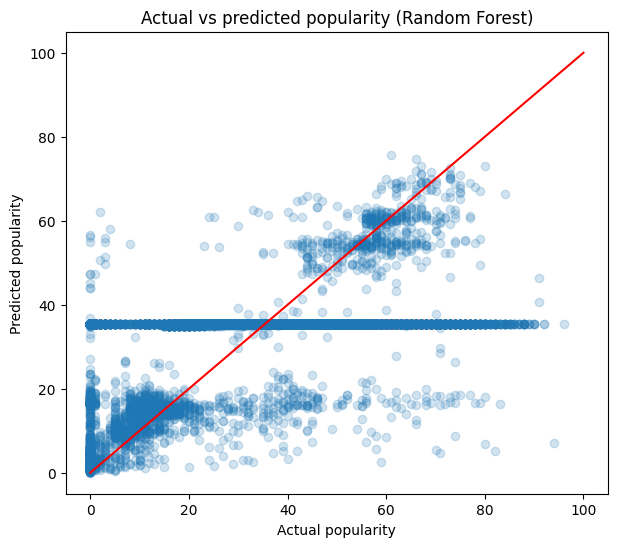

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred, alpha=0.2)
plt.plot([0, 100], [0, 100], color="red")   # perfect-prediction line
plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")
plt.title("Actual vs predicted popularity (Random Forest)")
plt.show()

In [20]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)

for name, m in {"Linear Regression": LinearRegression(), "Random Forest": rf}.items():
    cv = cross_val_score(m, X, y, cv=kf, scoring="r2")
    print(name, cv.round(3), f"mean {cv.mean():.3f} ± {cv.std():.3f}")

Linear Regression [0.32  0.334 0.325 0.331 0.328] mean 0.328 ± 0.005
Random Forest [0.19  0.201 0.192 0.205 0.199] mean 0.197 ± 0.006
